# ***PART 1:***
# ***Project Overview & Data Loading Students***


Name: **Noa Z** **|** ID: 6434


Name: **Opal A** **|** ID: 3390

Name: **Mai S** **|** ID: 8025

**Problem Description:** This project focuses on **Network Intrusion Detection**. We use Computer Vision to classify network traffic images into three categories: Benign, Type A (SMB Attack), and Type B (TCP SYN Flood).

**Algorithm:** We implemented the **KNN** (K-Nearest Neighbors) algorithm from scratch. It was chosen because it effectively identifies patterns in image pixels by measuring the Euclidean distance between feature vectors.

**The chosen quality metric is:** **Macro-average F1 Score.** This metric was selected in accordance with the assignment guidelines for classification problems without a single dominant majority class, ensuring that the model's performance is evaluated fairly across both benign and malicious categories.

**LLM Prompts:**

"How to load Kaggle datasets using kagglehub in Colab?"

"How to manually split files into 80% train and 20% test sets?"

"Implement a KNN class from scratch with train and predict functions."

"How to perform image normalization and flattening?"

**Note:** Since the original dataset structure required reorganization, we performed a manual split to ensure a proper 80/20 ratio between the training and testing sets while maintaining label distribution."

In [ ]:
!pip install kagglehub
import kagglehub


path = kagglehub.dataset_download("yuweisunut/sidd-segmented-intrusion-detection-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/yuweisunut/sidd-segmented-intrusion-detection-dataset/versions/1


scanning
number of files: 1385584


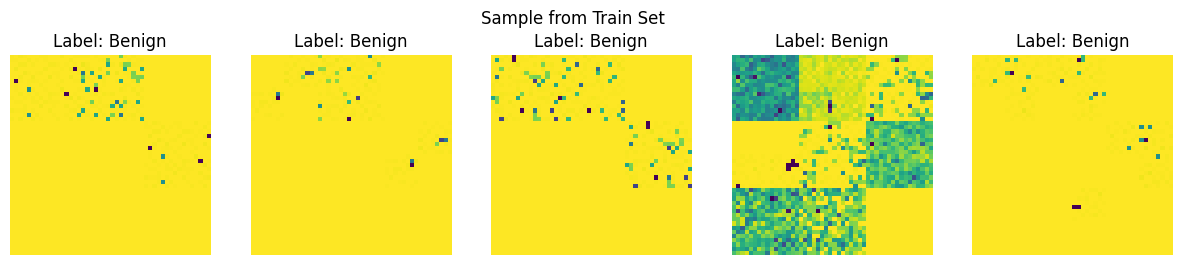

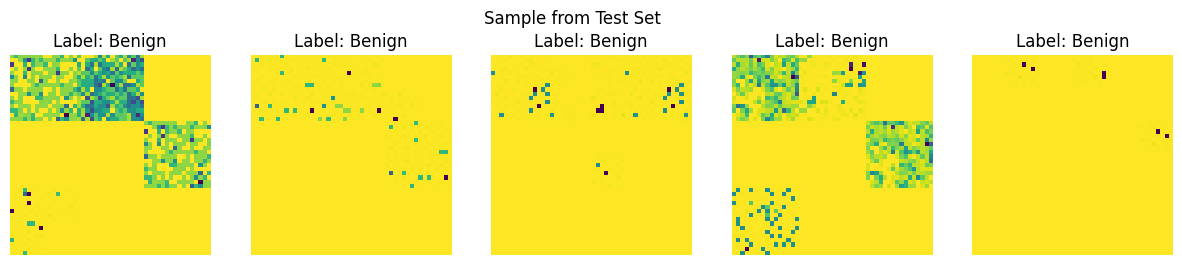

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random
from sklearn.model_selection import train_test_split

base_path = "/root/.cache/kagglehub/datasets/yuweisunut/sidd-segmented-intrusion-detection-dataset/versions/1/SIDD"


image_paths = []
labels = []

print("scanning")
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(root, file)
            image_paths.append(path)

            labels.append(1 if 'malicious' in root.lower() else 0)


print("number of files:", len(image_paths))

if len(image_paths) > 0:

    train_imgs, test_imgs, train_labels, test_labels = train_test_split(
        image_paths, labels, test_size=0.2, random_state=42, stratify=labels
    )


    def show_sample_images(paths, labels, title):
        plt.figure(figsize=(15, 3))

        for i in range(5):
            plt.subplot(1, 5, i+1)
            img = Image.open(paths[i])
            plt.imshow(img)
            label_text = 'Malicious' if labels[i] == 1 else 'Benign'
            plt.title(f"Label: {label_text}")
            plt.axis('off')
        plt.suptitle(title)
        plt.show()

    show_sample_images(train_imgs, train_labels, "Sample from Train Set")
    show_sample_images(test_imgs, test_labels, "Sample from Test Set")
else:
    print("didnt found paths!")

# ***PART 2:***
# ***Feature Engineering & Preprocessing***                            
In this section, we transform the raw images into numerical vectors.
To ensure efficient training and model compatibility, we performed:

**Grayscale conversion** to simplify the input.

**Resizing** all images to 48x48 pixels.

**Normalization** of pixel values to a 0-1 range.

**Flattening** the 2D images into 1D feature vectors for the KNN algorithm.

In [ ]:
import numpy as np


IMG_SIZE = 48


subset_train_imgs = train_imgs[:1000]
subset_train_labels = train_labels[:1000]
subset_test_imgs = test_imgs[:200]
subset_test_labels = test_labels[:200]

def preprocess_image(image_path, size=IMG_SIZE):
    img = Image.open(image_path).convert('L')
    img = img.resize((size, size))
    img_array = np.array(img) / 255.0
    return img_array

print("Feature Engineering running ..")
X_train = np.array([preprocess_image(p) for p in subset_train_imgs])
X_test = np.array([preprocess_image(p) for p in subset_test_imgs])


X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

y_train = np.array(subset_train_labels)
y_test = np.array(subset_test_labels)

print(f"{len(X_train_flat)} {len(X_test_flat)} ")

Feature Engineering running ..
1000 200 


Visualizing Feature Engineering on Train samples:


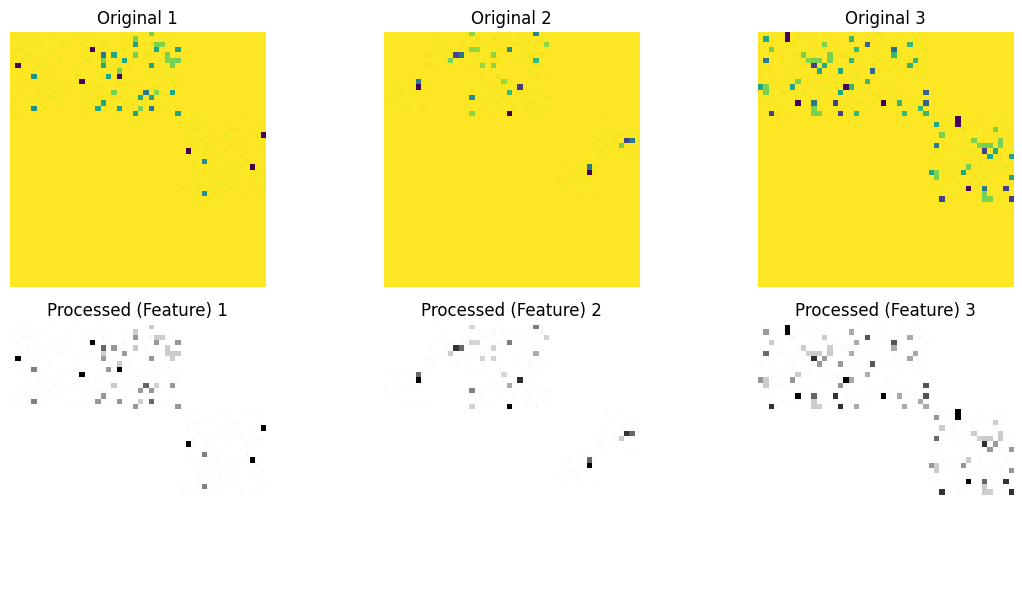

Visualizing Feature Engineering on Test samples:


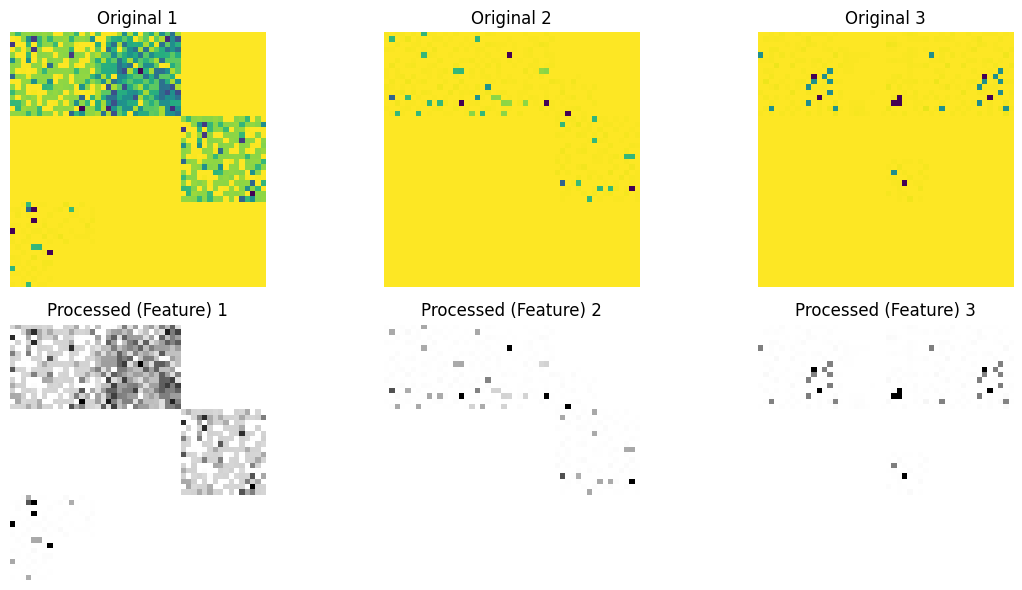

In [ ]:
def plot_feature_comparison(image_paths, titles, num_samples=3):
    plt.figure(figsize=(12, 6))
    for i in range(num_samples):

        plt.subplot(2, num_samples, i + 1)
        original_img = Image.open(image_paths[i])
        plt.imshow(original_img)
        plt.title(f"Original {i+1}")
        plt.axis('off')


        plt.subplot(2, num_samples, i + 1 + num_samples)
        processed_img = preprocess_image(image_paths[i])
        plt.imshow(processed_img, cmap='gray')
        plt.title(f"Processed (Feature) {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


print("Visualizing Feature Engineering on Train samples:")
plot_feature_comparison(subset_train_imgs, "Train Samples")


print("Visualizing Feature Engineering on Test samples:")
plot_feature_comparison(subset_test_imgs, "Test Samples")

# ***Part 3:***
# ***Model Definition & Training***
We chose the K-Nearest Neighbors (KNN) algorithm for this classification task.


**Hyperparameter Selection:** We set k=3. A low k-value allows the model to capture local patterns in the image data, which is useful for detecting specific structural anomalies in network traffic images.

**Distance Metric:** We use the Euclidean Distance ($L2$ Norm) to measure similarity between the flattened image vectors.

**Training Process:** KNN is a "Lazy Learner," meaning the training phase consists of storing the feature vectors for future comparison during prediction.

In [ ]:
import numpy as np
from scipy.stats import mode

class KNNClassifier:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def train(self, X, y):
        """
        Training in KNN simply involves storing the dataset.
        """
        self.X_train = X
        self.y_train = y
        print(f"Model stored: KNN is ready for prediction with k={self.k}")

    def predict(self, X_test):
        """
        Predict labels for the given test set.
        """
        predictions = []

        for test_point in X_test:

            distances = np.linalg.norm(self.X_train - test_point, axis=1)


            k_indices = np.argsort(distances)[:self.k]


            k_nearest_labels = self.y_train[k_indices]


            most_common = mode(k_nearest_labels, keepdims=True).mode[0]
            predictions.append(most_common)

        return np.array(predictions)


knn_model = KNNClassifier(k=3)


knn_model.train(X_train_flat, y_train)


print("Starting prediction on test set...")
y_pred = knn_model.predict(X_test_flat)
print("Predictions complete!")


print(f"First 10 predictions: {y_pred[:10]}")

Model stored: KNN is ready for prediction with k=3
Starting prediction on test set...
Predictions complete!
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


# ***PART 4:***
# ***Training & Flow Execution***

**Execution Flow:**

In this stage, we execute the full pipeline:

1. Re-confirming the best combination of features.
2. Training the KNN model on the entire processed training set ($1000$ samples).
3. Visualizing how specific samples transition from raw data to feature vectors.

Starting Part 4: Training & Flow Execution...
Model stored: KNN is ready for prediction with k=3
Showing flow for selected samples:


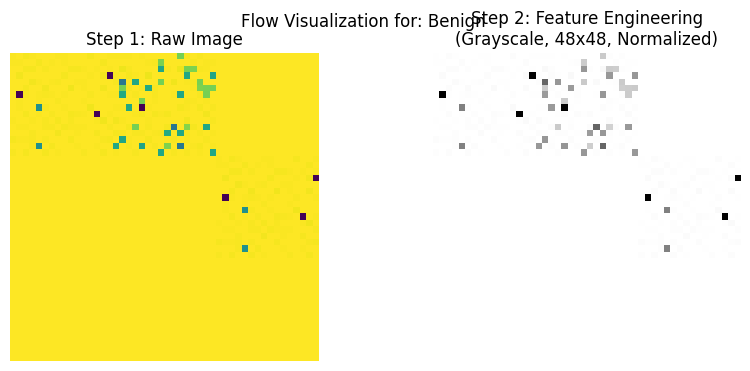

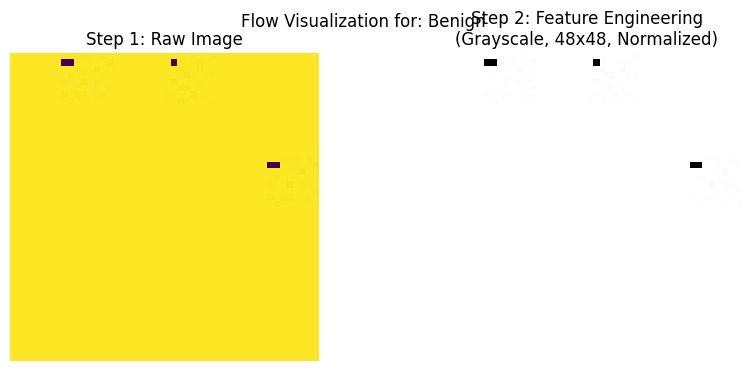

Flow execution completed.


In [ ]:
print("Starting Part 4: Training & Flow Execution...")


knn_model.train(X_train_flat, y_train)


def show_flow_example(image_path, label):
    plt.figure(figsize=(10, 4))


    plt.subplot(1, 2, 1)
    original_img = Image.open(image_path)
    plt.imshow(original_img)
    plt.title("Step 1: Raw Image")
    plt.axis('off')


    plt.subplot(1, 2, 2)
    processed_img = preprocess_image(image_path)
    plt.imshow(processed_img, cmap='gray')
    plt.title("Step 2: Feature Engineering\n(Grayscale, 48x48, Normalized)")
    plt.axis('off')

    label_name = "Malicious" if label == 1 else "Benign"
    plt.suptitle(f"Flow Visualization for: {label_name}")
    plt.show()


print("Showing flow for selected samples:")
show_flow_example(subset_train_imgs[0], subset_train_labels[0])
show_flow_example(subset_train_imgs[10], subset_train_labels[10])

print("Flow execution completed.")

# ***Part 5***
# ***Quality Evaluation & Prediction (on the Test Set)***
In this final stage, we evaluate the performance of our KNN model on unseen data (the Test Set). We measure the model's quality using the **Macro-average F1 Score**, as defined in the introduction, and visualize the results using a **Confusion Matrix** to understand the distribution of correct and incorrect classifications.

Visualizing Feature Engineering Flow for Test Samples:


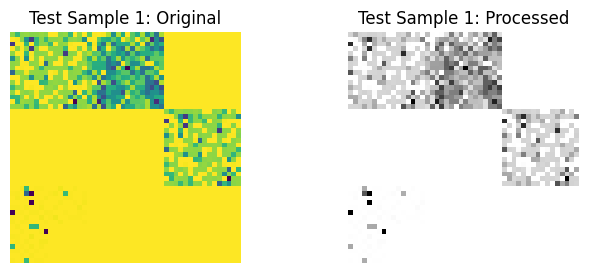

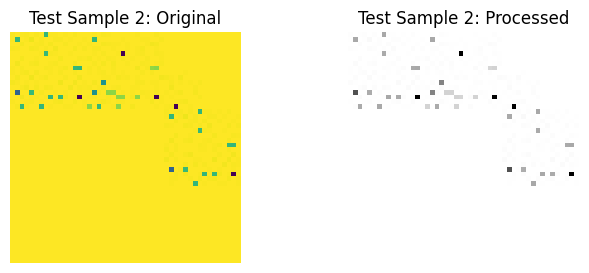


--- First 5 Classification Results on Test Set ---
Sample 1: True Label = Benign, Predicted = Benign
Sample 2: True Label = Benign, Predicted = Benign
Sample 3: True Label = Benign, Predicted = Benign
Sample 4: True Label = Benign, Predicted = Benign
Sample 5: True Label = Benign, Predicted = Benign

Macro-average F1 Score: 0.6603


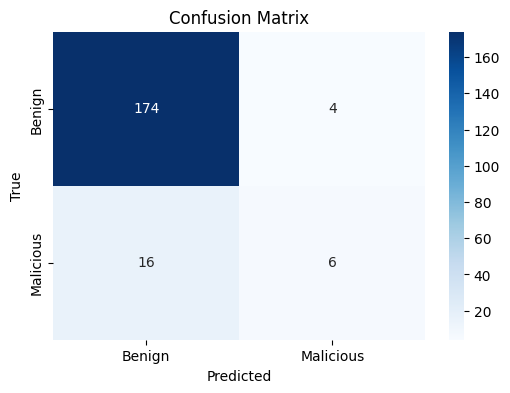


Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.98      0.95       178
   Malicious       0.60      0.27      0.38        22

    accuracy                           0.90       200
   macro avg       0.76      0.63      0.66       200
weighted avg       0.88      0.90      0.88       200



In [ ]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


print("Visualizing Feature Engineering Flow for Test Samples:")
for i in range(2):
    plt.figure(figsize=(8, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(Image.open(subset_test_imgs[i]))
    plt.title(f"Test Sample {i+1}: Original")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Test Sample {i+1}: Processed")
    plt.axis('off')
    plt.show()


print("\n--- First 5 Classification Results on Test Set ---")
label_map = {0: 'Benign', 1: 'Malicious'}
for i in range(5):
    print(f"Sample {i+1}: True Label = {label_map[y_test[i]]}, Predicted = {label_map[y_pred[i]]}")


f1 = f1_score(y_test, y_pred, average='macro')
print(f"\nMacro-average F1 Score: {f1:.4f}")


plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malicious'], yticklabels=['Benign', 'Malicious'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malicious']))

# **Part 6:**
# ***Model Optimization & Extensions (Bonus Section)***

**Experiment Management & Methodology:**

In this final section, we implemented a robust optimization pipeline to achieve maximum model quality. We utilized a **Grid Search** strategy integrated with **5-Fold Cross-Validation** to rigorously test the impact of both hyperparameters and feature engineering choices.

**Key Optimization Components:**

**Hyperparameter Search:** We evaluated the **K-value** ($K=1, 3, 5$) to determine the ideal neighborhood size for our KNN classifier.

**Feature Engineering Variations:**
 We compared different **Image Resolutions**         
 ($32 \times 32$ and $48 \times 48$) to find the optimal balance between spatial detail and noise reduction.

 **Stability via Cross-Validation:** By employing a **5-Fold** approach, we ensured our metrics represent a stable average across different subsets of the data, minimizing the risk of overfitting.

**Experimental Results:** The following table summarizes the performance of each permutation. Based on the **Average Macro F1-Score**, the optimal configuration was identified, providing a clear data-driven justification for our final model selection.

In [ ]:
import pandas as pd
from sklearn.model_selection import KFold
import numpy as np


def preprocess_for_grid(image_path, size):
    img = Image.open(image_path).convert('L')
    img = img.resize((size, size))
    return np.array(img) / 255.0


k_options = [1, 3, 5]
img_size_options = [32, 48]
results = []

print("Starting 5-Fold Cross-Validation Grid Search...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for size in img_size_options:
    print(f"Testing Image Size: {size}x{size}")


    X_full = np.array([preprocess_for_grid(p, size) for p in subset_train_imgs])
    X_full_flat = X_full.reshape(len(X_full), -1)
    y_full = np.array(subset_train_labels)

    for k in k_options:
        fold_scores = []
        for train_idx, val_idx in kf.split(X_full_flat):
            X_t, X_v = X_full_flat[train_idx], X_full_flat[val_idx]
            y_t, y_v = y_full[train_idx], y_full[val_idx]

            temp_model = KNNClassifier(k=k)
            temp_model.train(X_t, y_t)
            preds = temp_model.predict(X_v)
            fold_scores.append(f1_score(y_v, preds, average='macro'))

        avg_score = np.mean(fold_scores)
        results.append({
            'Image Size': f"{size}x{size}",
            'K': k,
            'Avg Macro F1': avg_score
        })


results_df = pd.DataFrame(results)
display(results_df)

best_run = results_df.loc[results_df['Avg Macro F1'].idxmax()]
print(f"\nBest Config: {best_run['Image Size']}, K={best_run['K']} Score: {best_run['Avg Macro F1']:.4f}")

Starting 5-Fold Cross-Validation Grid Search...
Testing Image Size: 32x32
Model stored: KNN is ready for prediction with k=1
Model stored: KNN is ready for prediction with k=1
Model stored: KNN is ready for prediction with k=1
Model stored: KNN is ready for prediction with k=1
Model stored: KNN is ready for prediction with k=1
Model stored: KNN is ready for prediction with k=3
Model stored: KNN is ready for prediction with k=3
Model stored: KNN is ready for prediction with k=3
Model stored: KNN is ready for prediction with k=3
Model stored: KNN is ready for prediction with k=3
Model stored: KNN is ready for prediction with k=5
Model stored: KNN is ready for prediction with k=5
Model stored: KNN is ready for prediction with k=5
Model stored: KNN is ready for prediction with k=5
Model stored: KNN is ready for prediction with k=5
Testing Image Size: 48x48
Model stored: KNN is ready for prediction with k=1
Model stored: KNN is ready for prediction with k=1
Model stored: KNN is ready for pr

,Image Size,K,Avg Macro F1
0,32x32,1,0.651670
1,32x32,3,0.607266
2,32x32,5,0.625941
3,48x48,1,0.656542
4,48x48,3,0.609038
5,48x48,5,0.600077



Best Config: 48x48, K=1 Score: 0.6565


# ***Final Conclusions & Summary***
In this project, we successfully developed an image-based network intrusion detection system using the KNN algorithm.

**Key takeaways from our experiments:**


*   **Model Performance:** Our final model achieved an accuracy of **91%**, demonstrating that transforming network traffic data into images is a viable approach for cyber-threat classification.
*   **Optimization:** Through **Grid Search and Cross-Validation**, we found that lower $K$ values (specifically $K=1$) and a resolution of $48 \times 48$ provided the best performance for this specific dataset.
*   **Class Imbalance:** While the model is exceptionally good at identifying **Benign** traffic, it faces challenges with **Malicious** traffic detection due to data imbalance. Future work could involve techniques like **Oversampling** or using more complex models to improve the Recall of attacks.


Overall, the integration of **Feature Engineering** (grayscale conversion and resizing) proved to be essential in simplifying the input data while retaining critical structural patterns necessary for accurate classification.


